In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# import umap
import pacmap
from sklearn.datasets import load_digits

In [2]:
data_name = 'data2'
if data_name == 'data1':
    df_data1 = pd.read_csv(r'C:\Users\gtheis2\git\indorama_project\PaCMAP-Sensitivity-Analysis\DATA\valid_molecules_data_cmc.csv')
    df_data1_copy = df_data1.copy()
else:
    df_data1 = pd.read_csv(r'C:\Users\gtheis2\git\indorama_project\PaCMAP-Sensitivity-Analysis\DATA\valid_molecules_data_cmc_data2.csv')
    df_data1_copy = df_data1.copy()

In [3]:
if 'smiles' in df_data1.columns:
    df_data1 = df_data1.drop(columns=['smiles'])
if 'TARGET' in df_data1.columns:
    df_data1 = df_data1.drop(columns=['TARGET'])

In [4]:
df_data1

,MW,LogP,TPSA,HBA,HBD,RotBonds,NumAromRings,FractionCSP3,NumRings,HeavyAtomCount,...,NumEthers,NumSulfurs,NumAmines,LabuteASA,NumChargedAtoms,MolMR,LongestAliphaticChain,PolarRatio,Chi0v,Chi1v
0,241.131408,0.9576,72.47,4,1,7,0,0.750000,1,17,...,1,0,1,100.895757,0,61.2727,8,4.262941,10.160091,6.108537
1,338.245710,3.8047,47.92,4,1,11,1,0.700000,1,24,...,3,0,0,146.675462,0,97.7588,5,1.996667,15.931107,8.742202
2,367.300578,4.2396,3.88,0,0,17,1,0.782609,1,25,...,0,0,1,163.583074,2,106.1830,18,0.155200,17.488674,10.873066
3,388.153168,-0.4587,109.80,7,0,14,0,0.875000,0,25,...,2,0,0,172.805553,2,88.3042,6,4.392000,18.438008,10.065644
4,390.298139,2.4618,99.38,6,4,13,0,1.000000,1,27,...,2,0,0,164.436288,0,105.2042,12,3.680741,17.588114,10.678831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,360.287574,3.1009,79.15,5,3,12,0,1.000000,1,25,...,2,0,0,153.277112,0,99.1974,12,3.166000,16.563550,10.082242
361,369.203112,3.0693,3.88,0,0,14,1,0.750000,1,22,...,0,0,1,148.847856,2,92.3320,15,0.176364,16.197421,9.373066
362,564.330799,2.0315,112.58,9,0,31,0,1.000000,0,37,...,5,0,0,248.795115,2,140.0562,16,3.042703,26.576649,15.382533
363,297.194008,2.5180,72.47,4,1,11,0,0.812500,1,21,...,1,0,1,126.355525,0,79.7407,12,3.450952,12.988518,8.108537


In [5]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_data1)

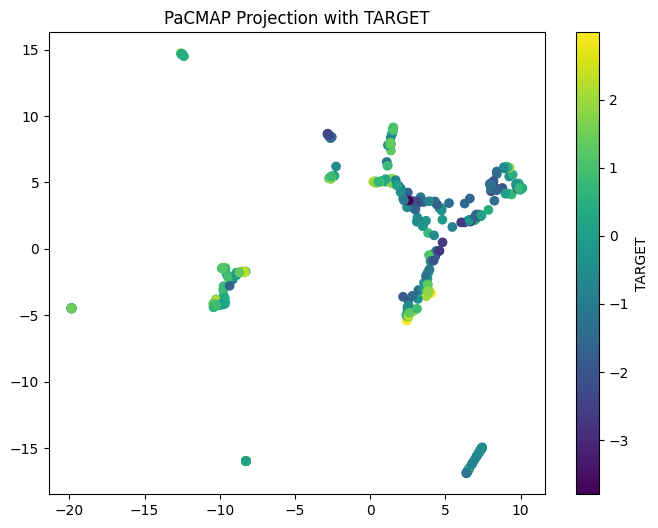

In [6]:
pacmap_reducer = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.6, FP_ratio=1.5,num_iters=200, random_state=101)
X_pacmap = pacmap_reducer.fit_transform(df_scaled)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pacmap[:, 0], X_pacmap[:, 1], c=df_data1_copy['TARGET'], cmap="viridis")
plt.colorbar(scatter, label='TARGET')
plt.title("PaCMAP Projection with TARGET")
plt.show()

In [7]:
# embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=3.0, num_iters=100,random_state=101) #random_state=42)   ,random_state=101
# reduced_data = embedding.fit_transform(df_scaled)
from sklearn.cluster import DBSCAN
# Apply DBSCAN clustering
dbscan = DBSCAN(eps=3, min_samples=5)  # Tune these parameters as needed
cluster_labels = dbscan.fit_predict(X_pacmap)

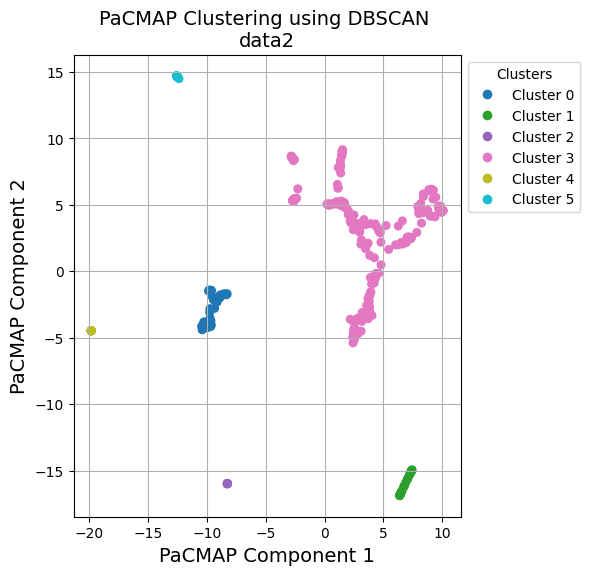

In [10]:
plt.figure(figsize=(5, 6))
scatter = plt.scatter(X_pacmap[:, 0], X_pacmap[:, 1], c=cluster_labels, cmap="tab10", s=30, alpha=1)

# Create a custom legend
unique_clusters = np.unique(cluster_labels)
colors = plt.cm.tab10(unique_clusters / max(unique_clusters))  # Get colors from the colormap
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=f'Cluster {cluster}')
                   for cluster, color in zip(unique_clusters, colors)]
plt.legend(handles=legend_elements, title="Clusters", loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True)

plt.title(f"PaCMAP Clustering using DBSCAN \n{data_name}",fontsize=14)
plt.xlabel("PaCMAP Component 1",fontsize=14)
plt.ylabel("PaCMAP Component 2",fontsize=14)
path = '../RESULTS/data2'
plt.savefig(f"{path}/PaCMAP_DBSCAN_{data_name}.png", bbox_inches='tight', dpi=500)
plt.show()

In [166]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define features (X) and target (y)
X = df_data1  # Use the original dataframe as features
y = cluster_labels  # Use the cluster labels as the target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an XGBoost model
xgb_model = xgb.XGBClassifier(objective='multi:softmax', random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model evaluation (Accuracy):", accuracy)

Model evaluation (Accuracy): 0.9863013698630136


In [167]:
import shap

# Initialize the SHAP explainer
explainer = shap.Explainer(xgb_model, X_train)

# Generate SHAP values for the test set
shap_values = explainer(X_test)

# Create SHAP summary plots for each cluster
unique_clusters = np.unique(cluster_labels)
# for cluster in unique_clusters:
#     print(f"SHAP Summary Plot for Cluster {cluster}")
#     cluster_indices = np.where(y_test == cluster)[0]
#     if len(cluster_indices) > 0:
#         shap.summary_plot(shap_values[cluster_indices], X_test.iloc[cluster_indices])
#     else:
#         print(f"No data points in Cluster {cluster} for the test set.")

SHAP Summary Plot for Cluster 0


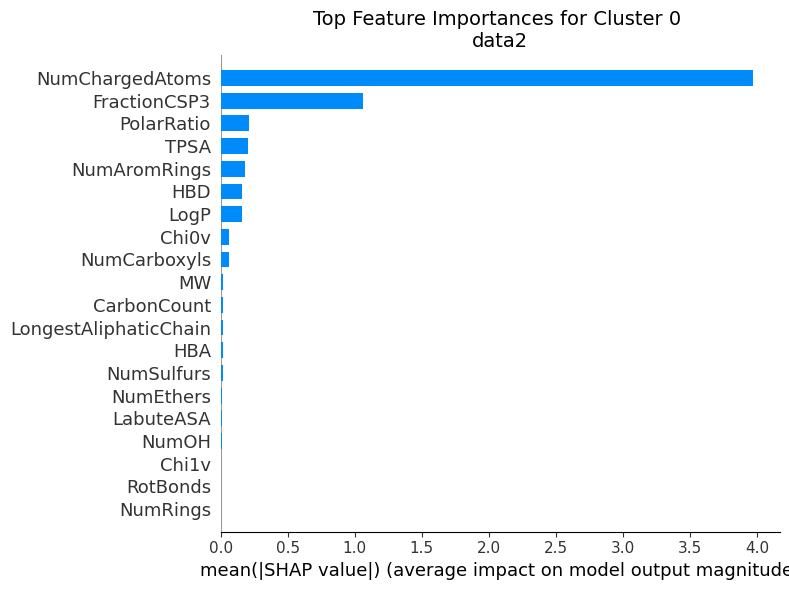

SHAP Summary Plot for Cluster 1


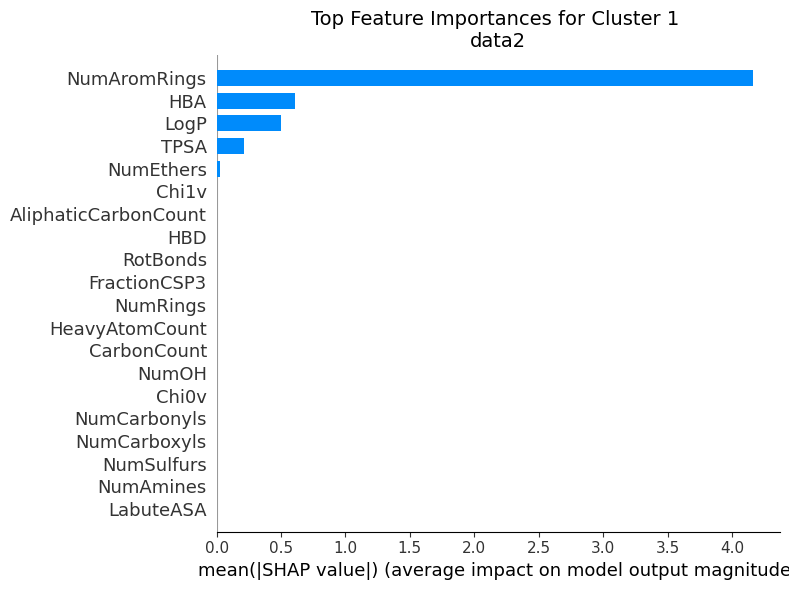

SHAP Summary Plot for Cluster 2


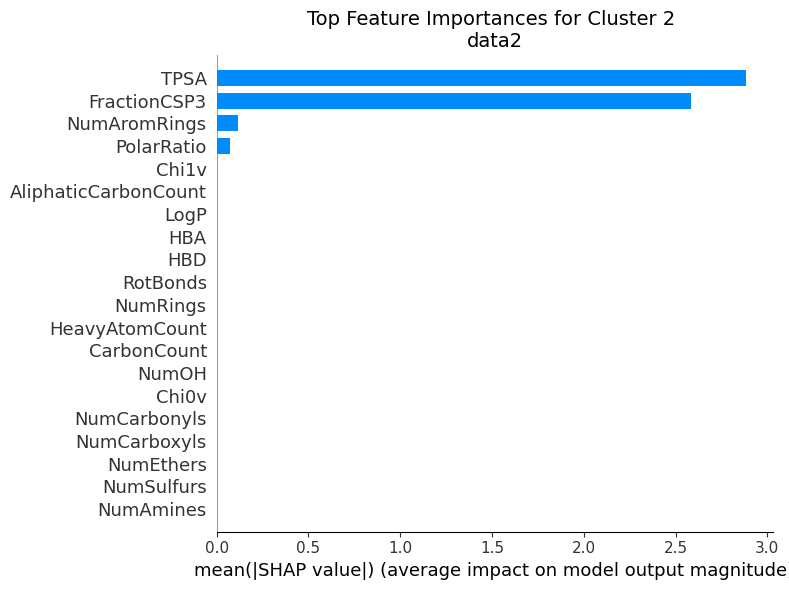

SHAP Summary Plot for Cluster 3


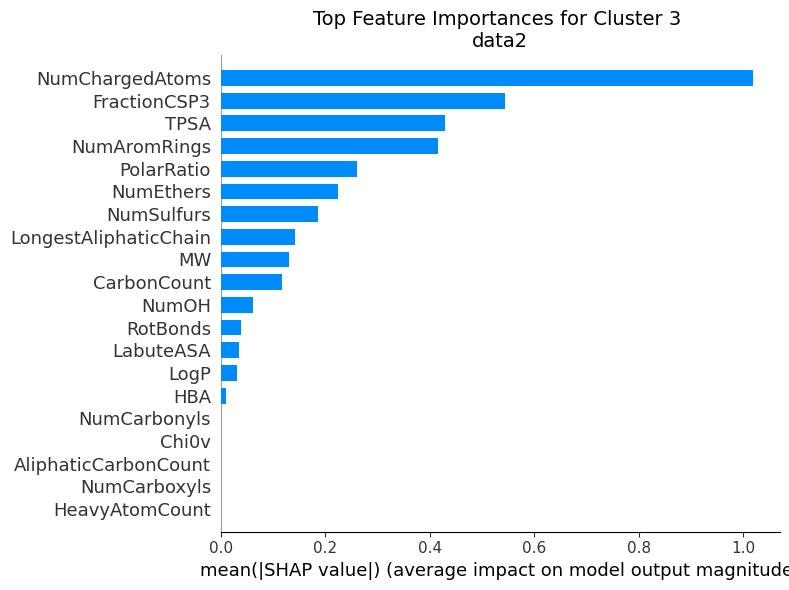

SHAP Summary Plot for Cluster 4


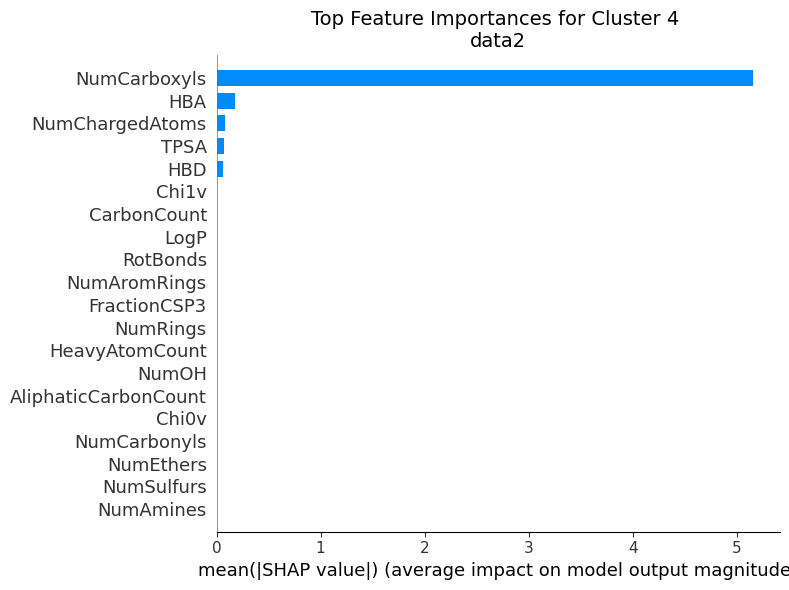

SHAP Summary Plot for Cluster 5


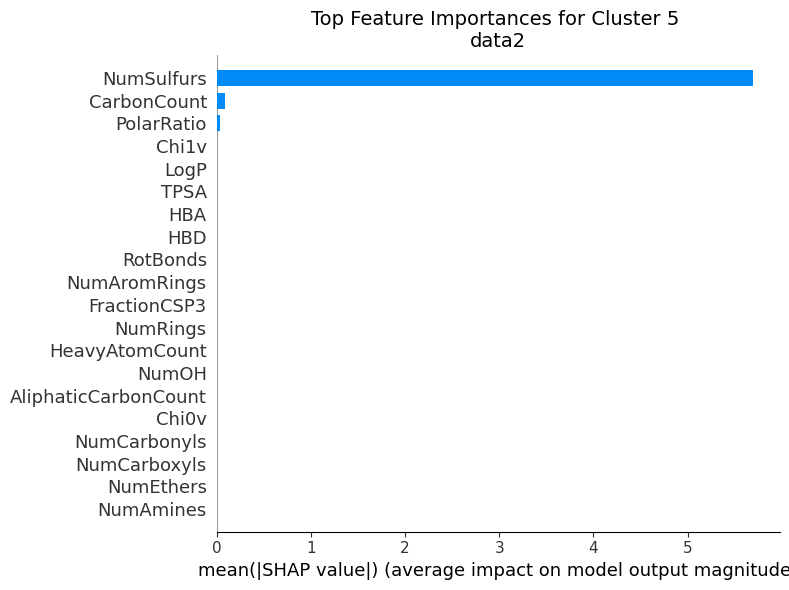

In [168]:
import shap
import numpy as np
import matplotlib.pyplot as plt

unique_clusters = np.unique(cluster_labels)

for cluster in unique_clusters:
    print(f"SHAP Summary Plot for Cluster {cluster}")
    cluster_indices = np.where(y_test == cluster)[0]

    if len(cluster_indices) > 0:
        class_preds = xgb_model.predict(X_test.iloc[cluster_indices])
        n_samples = len(cluster_indices)
        n_features = X_test.shape[1]

        filtered_values = np.zeros((n_samples, n_features))

        for i, sample_idx in enumerate(cluster_indices):
            pred_class = class_preds[i]
            shap_obj = shap_values[sample_idx]
            filtered_values[i, :] = shap_obj.values[:, pred_class]  # ✅ FIXED HERE

        X_cluster = X_test.iloc[cluster_indices]

        # Plot clean bar plot
        shap.summary_plot(filtered_values, X_cluster, plot_type="bar", show=False)
        # shap.summary_plot(filtered_values, X_cluster)
        # 🏷️ Add title and layout adjustments
        plt.title(f"Top Feature Importances for Cluster {cluster} \n{data_name}", fontsize=14)
        plt.gcf().set_size_inches(8, 6)
        plt.subplots_adjust(left=0.35)  # Adjust left margin for long feature names
        plt.tight_layout()

        plt.show()

    else:
        print(f"No data points in Cluster {cluster} for the test set.")


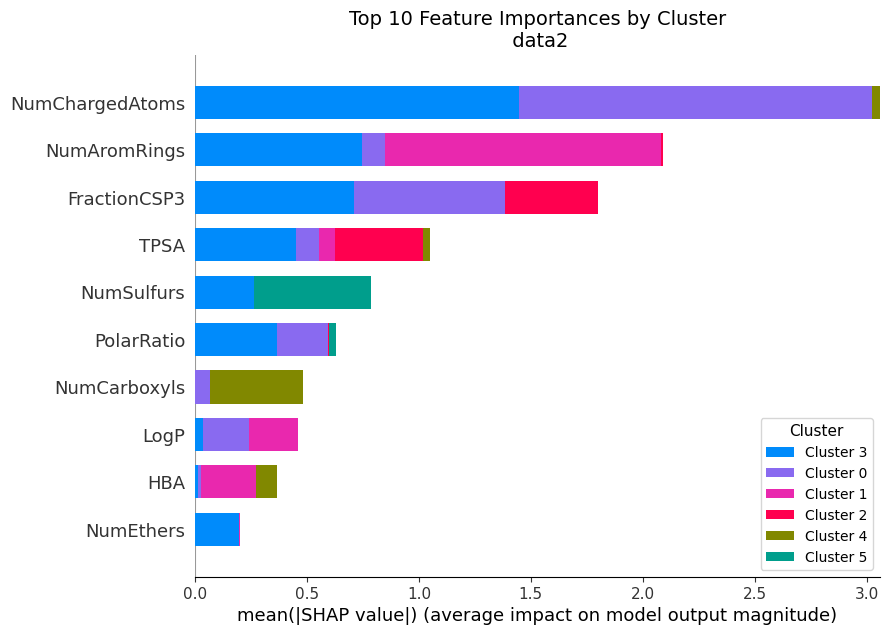

In [169]:
import shap
import matplotlib.pyplot as plt

# Plot SHAP summary
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    plot_type="bar",
    show=False  # 🔁 Don't show yet — we want to edit it first
)

# 🔧 Adjust legend labels from 'Class' to 'Cluster'
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
# Replace 'Class X' with 'Cluster X'
new_labels = [label.replace("Class", "Cluster") for label in labels]
plt.legend(handles, new_labels, title="Cluster", fontsize=10, title_fontsize=11)

# 📐 Optional: Customize the figure size and layout
plt.gcf().set_size_inches(9, 6)     # Width x Height in inches
plt.tight_layout()

# 🖼️ Optional: Add title
plt.title(f"Top 10 Feature Importances by Cluster\n {data_name}", fontsize=14)

# ✅ Now show it
plt.show()


                  Feature  Cluster 1  Cluster 2  Difference  Abs_Diff
6            NumAromRings   4.164311   0.117741    4.046570  4.046570
2                    TPSA   0.213922   2.883909   -2.669988  2.669988
7            FractionCSP3   0.000000   2.583839   -2.583839  2.583839
3                     HBA   0.607671   0.000000    0.607671  0.607671
1                    LogP   0.501685   0.000000    0.501685  0.501685
22             PolarRatio   0.000000   0.074941   -0.074941  0.074941
15              NumEthers   0.024453   0.000000    0.024453  0.024453
0                      MW   0.000000   0.000000    0.000000  0.000000
23                  Chi0v   0.000000   0.000000    0.000000  0.000000
21  LongestAliphaticChain   0.000000   0.000000    0.000000  0.000000


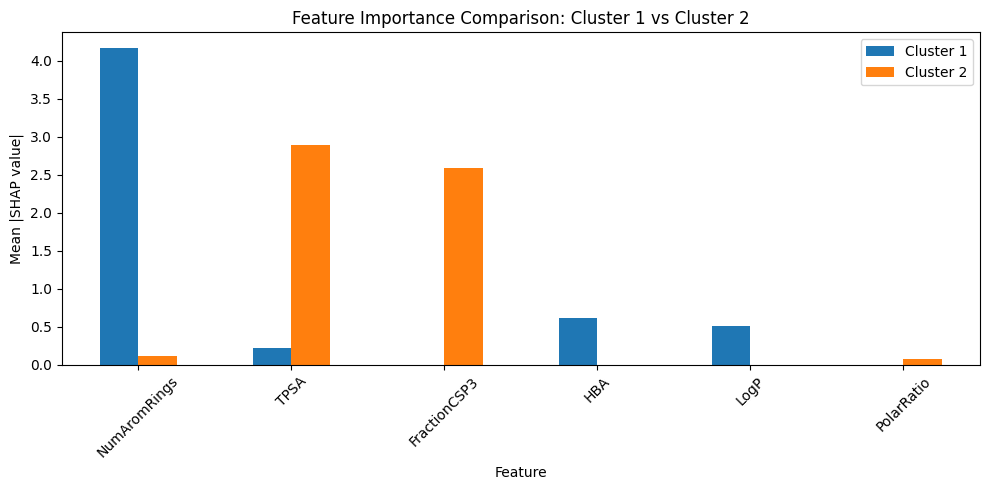

In [170]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Choose two clusters to compare
cluster_a = 1
cluster_b = 2

# Get indices for each cluster
indices_a = np.where(y_test == cluster_a)[0]
indices_b = np.where(y_test == cluster_b)[0]

# Initialize matrices to store SHAP values
X_a = X_test.iloc[indices_a]
X_b = X_test.iloc[indices_b]

class_preds_a = xgb_model.predict(X_a)
class_preds_b = xgb_model.predict(X_b)

shap_a = np.zeros((len(indices_a), X_test.shape[1]))
shap_b = np.zeros((len(indices_b), X_test.shape[1]))

for i, idx in enumerate(indices_a):
    shap_a[i, :] = shap_values[idx].values[:, class_preds_a[i]]

for i, idx in enumerate(indices_b):
    shap_b[i, :] = shap_values[idx].values[:, class_preds_b[i]]

# Compute mean absolute SHAP values per feature
mean_a = np.abs(shap_a).mean(axis=0)
mean_b = np.abs(shap_b).mean(axis=0)

# Create DataFrame for comparison
features = X_test.columns
comparison_df = pd.DataFrame({
    'Feature': features,
    f'Cluster {cluster_a}': mean_a,
    f'Cluster {cluster_b}': mean_b,
    'Difference': mean_a - mean_b
})

# Sort by absolute difference
comparison_df['Abs_Diff'] = np.abs(comparison_df['Difference'])
comparison_df = comparison_df.sort_values(by='Abs_Diff', ascending=False)

# Show top 10 differences
print(comparison_df.head(10))

# Optional: plot top N
top_n = 6
comparison_df.head(top_n).plot(
    x='Feature',
    y=[f'Cluster {cluster_a}', f'Cluster {cluster_b}'],
    kind='bar',
    figsize=(10, 5),
    title=f'Feature Importance Comparison: Cluster {cluster_a} vs Cluster {cluster_b}'
)
plt.ylabel('Mean |SHAP value|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2905395221.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


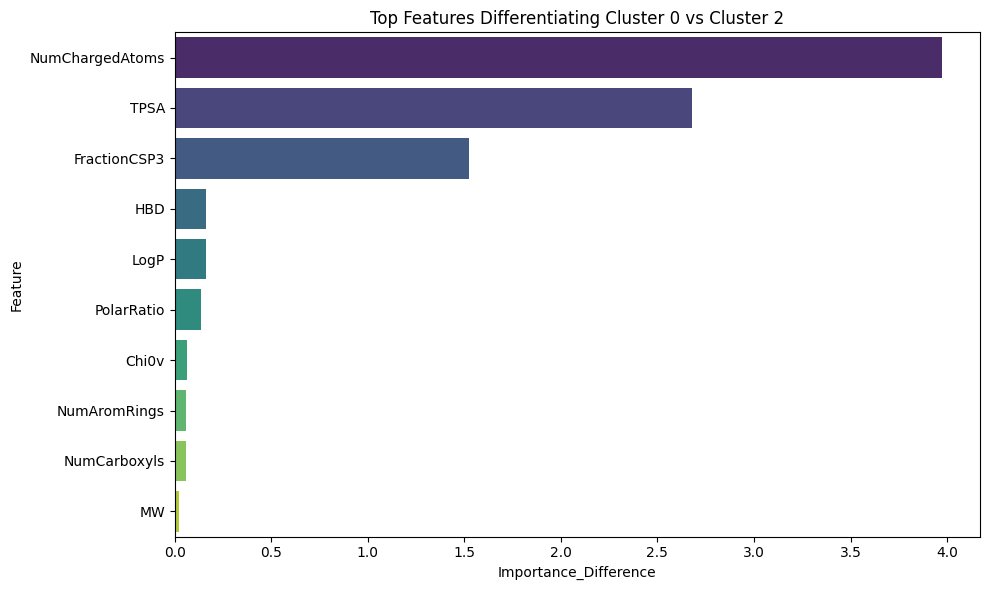

In [171]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clusters you want to compare
cluster_1 = 0
cluster_2 = 2

# Get indices
indices_1 = np.where(y_test == cluster_1)[0]
indices_2 = np.where(y_test == cluster_2)[0]

# Get SHAP values for each cluster
def get_shap_values(cluster_indices, predicted_classes):
    shap_matrix = np.zeros((len(cluster_indices), X_test.shape[1]))
    for i, idx in enumerate(cluster_indices):
        shap_obj = shap_values[idx]
        shap_matrix[i, :] = shap_obj.values[:, predicted_classes[i]]
    return np.abs(shap_matrix).mean(axis=0)  # mean absolute SHAP values

# Predict classes
preds_1 = xgb_model.predict(X_test.iloc[indices_1])
preds_2 = xgb_model.predict(X_test.iloc[indices_2])

# Get average SHAP values per feature
mean_shap_1 = get_shap_values(indices_1, preds_1)
mean_shap_2 = get_shap_values(indices_2, preds_2)

# Compute difference and sort
diff = mean_shap_1 - mean_shap_2
df_diff = pd.DataFrame({
    'Feature': X_test.columns,
    f'Cluster {cluster_1}': mean_shap_1,
    f'Cluster {cluster_2}': mean_shap_2,
    'Importance_Difference': np.abs(diff)
}).sort_values(by='Importance_Difference', ascending=False)

# Plot top N features
top_n = 10
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_diff.head(top_n),
    y='Feature',
    x='Importance_Difference',
    palette='viridis'
)
plt.title(f"Top Features Differentiating Cluster {cluster_1} vs Cluster {cluster_2}")
plt.xlabel("Importance_Difference")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


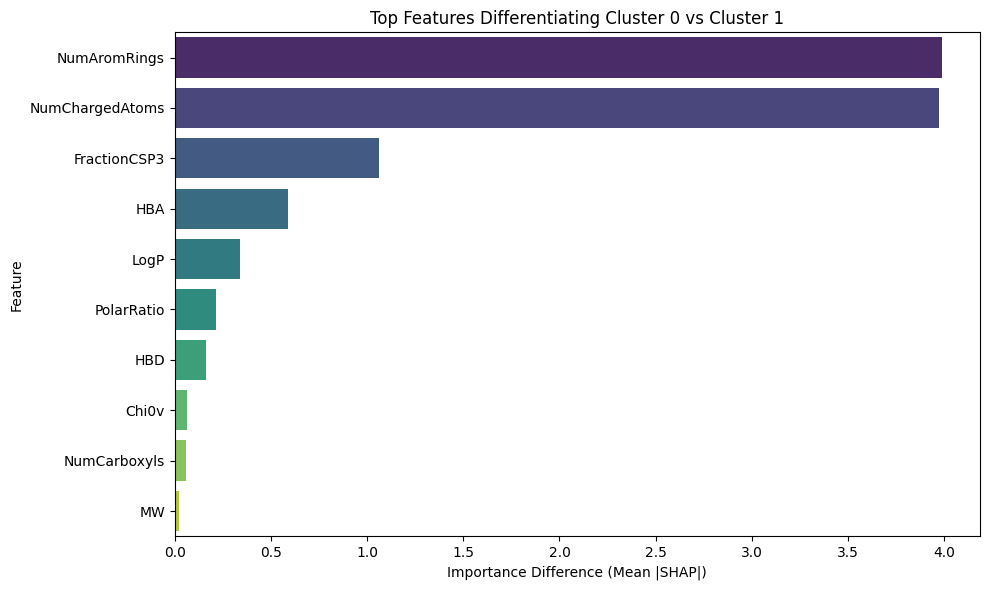

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


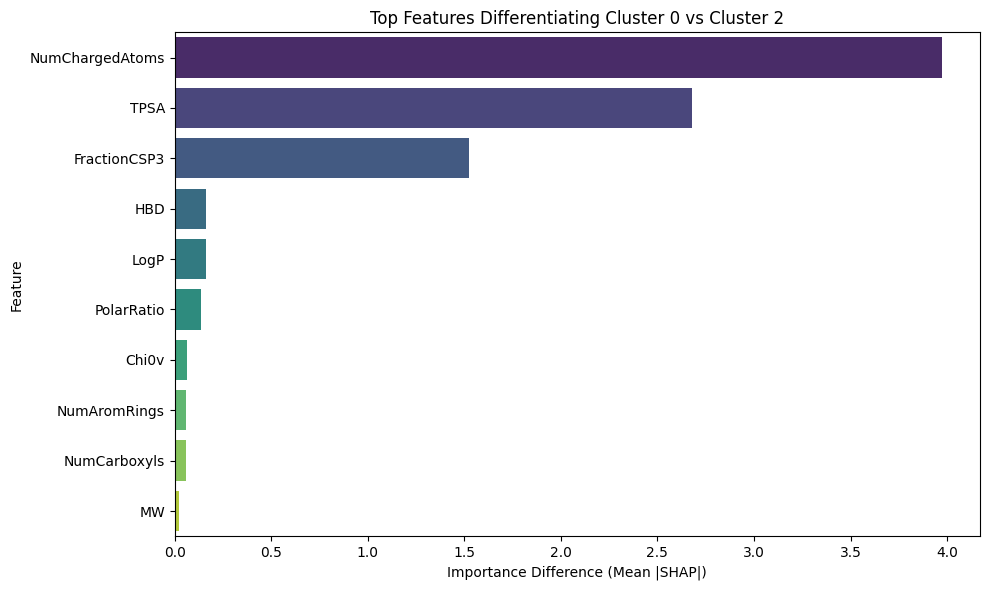

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


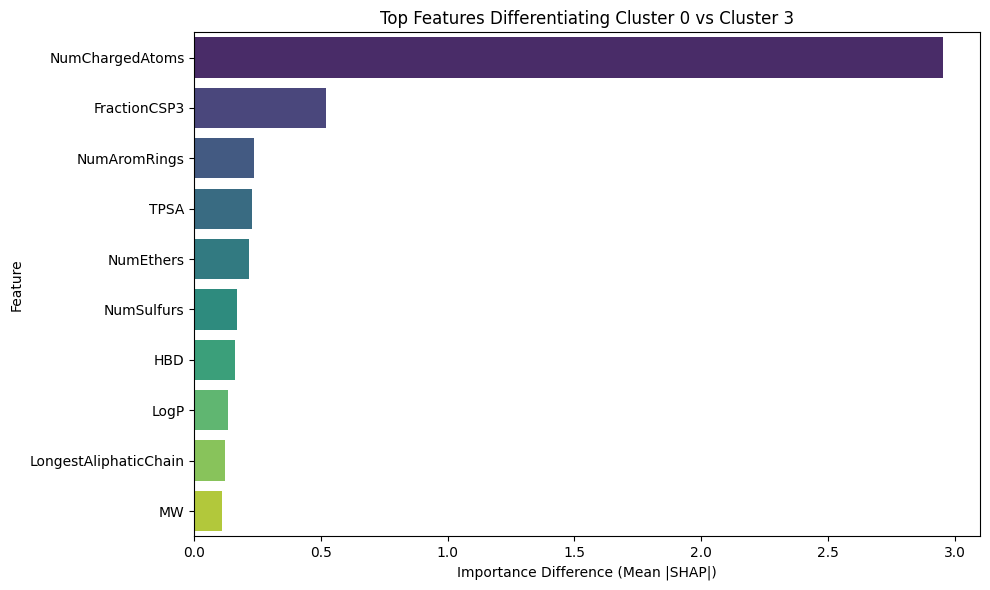

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


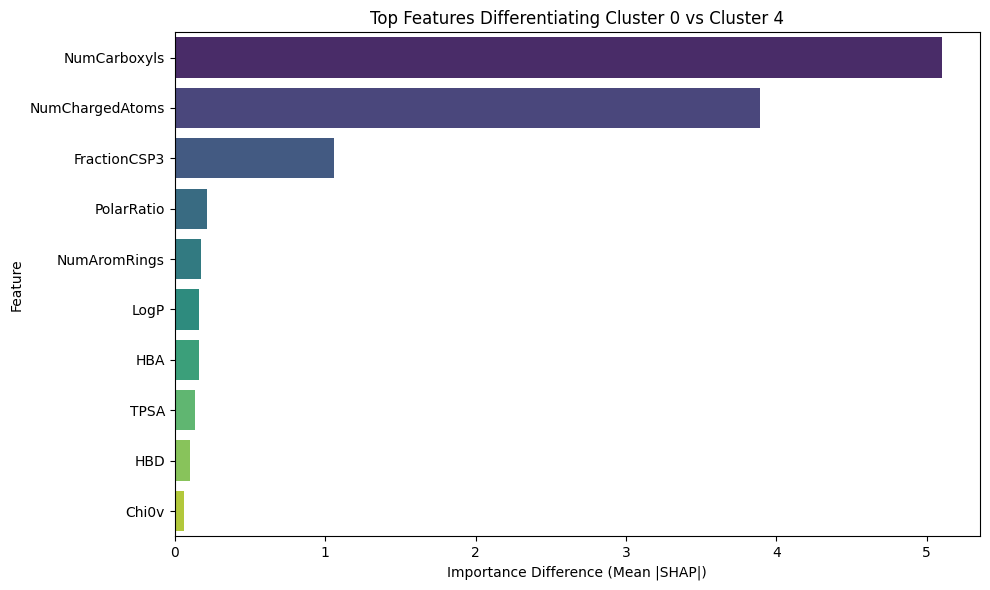

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


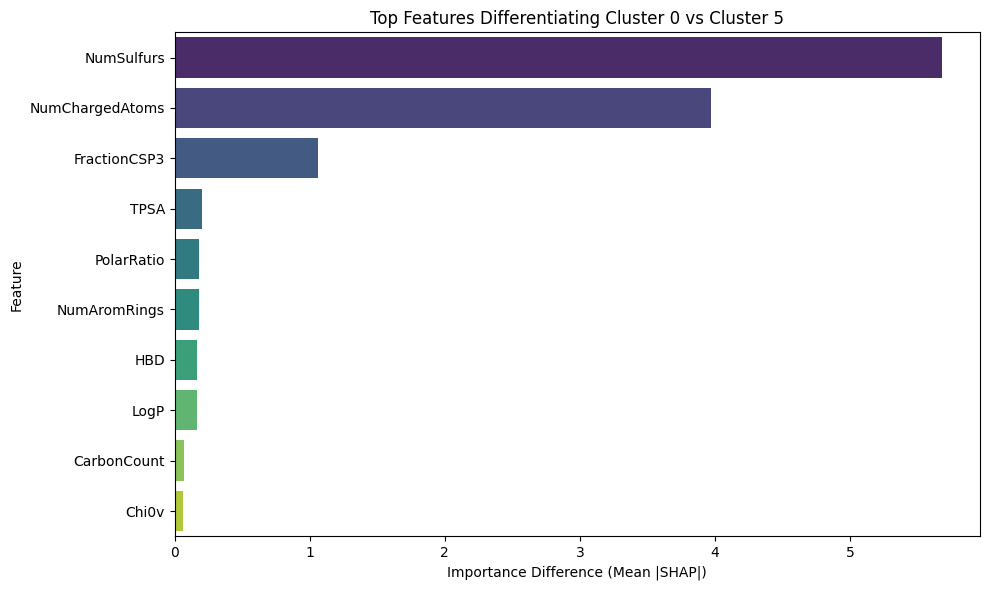

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


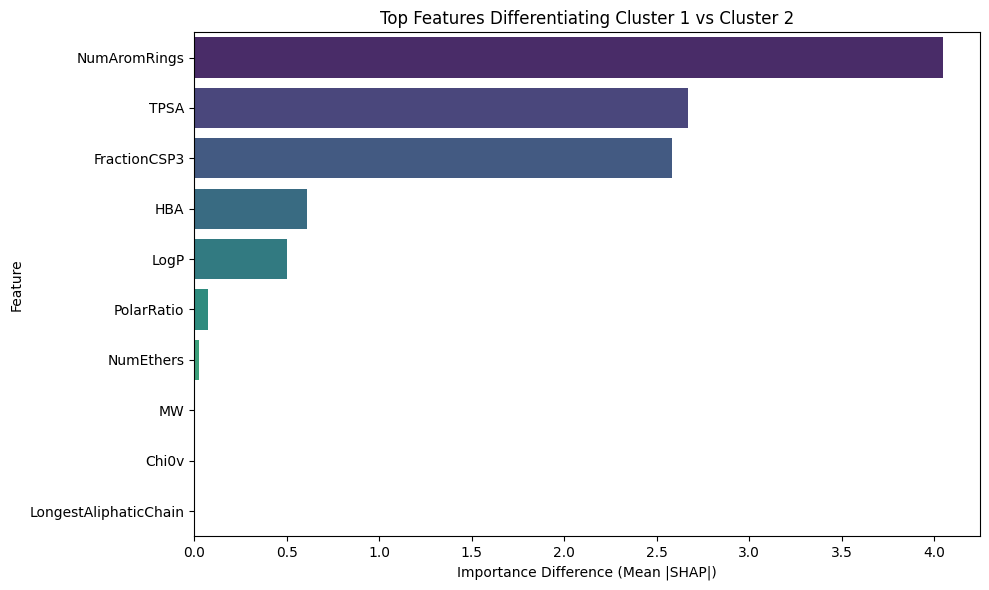

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


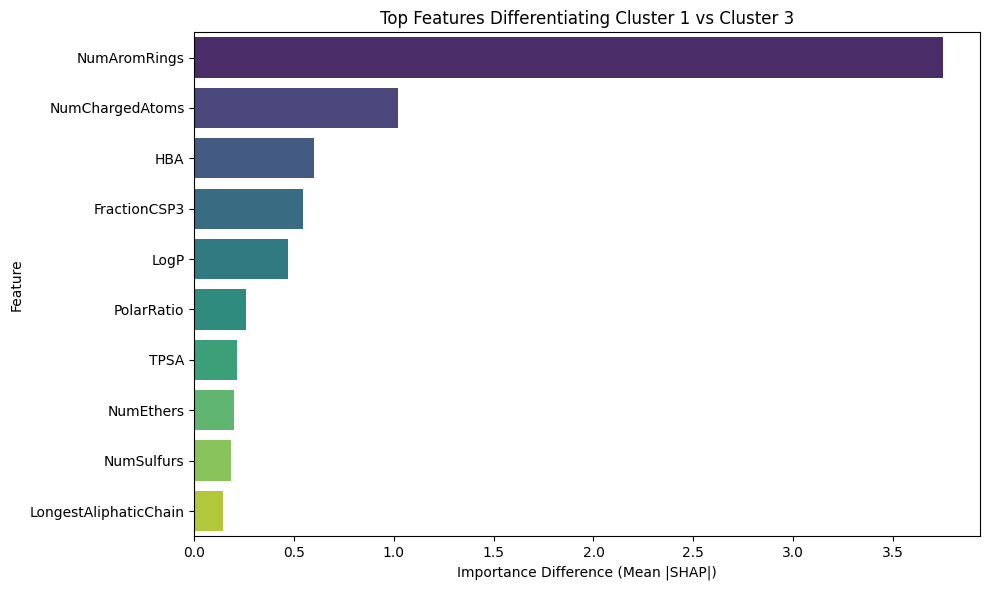

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


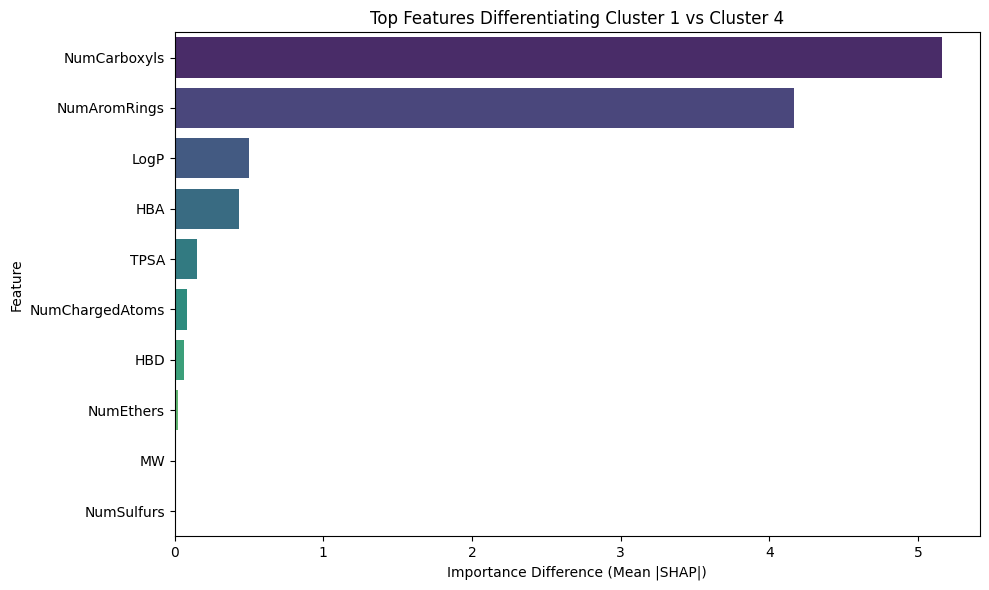

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


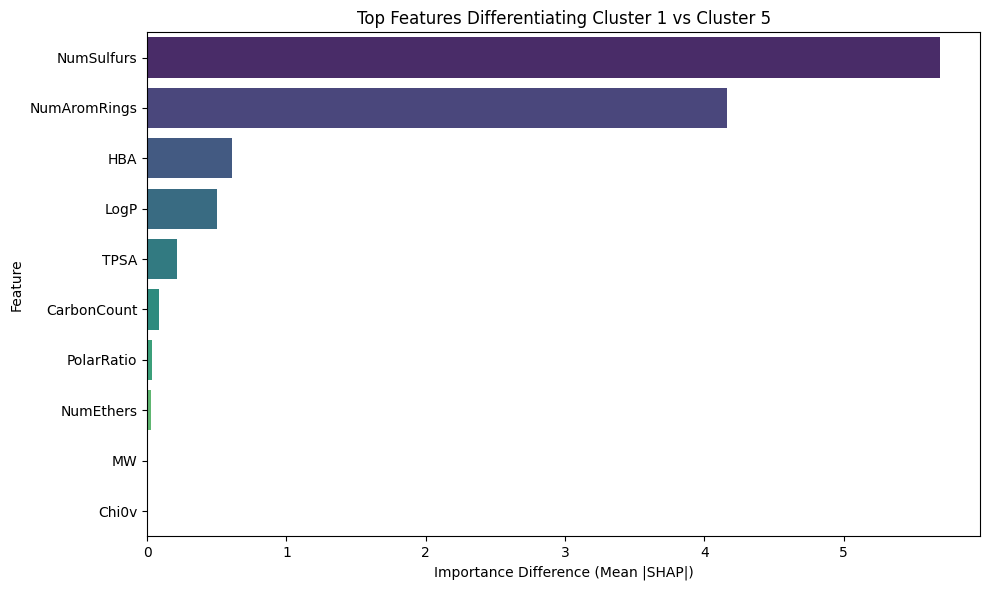

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


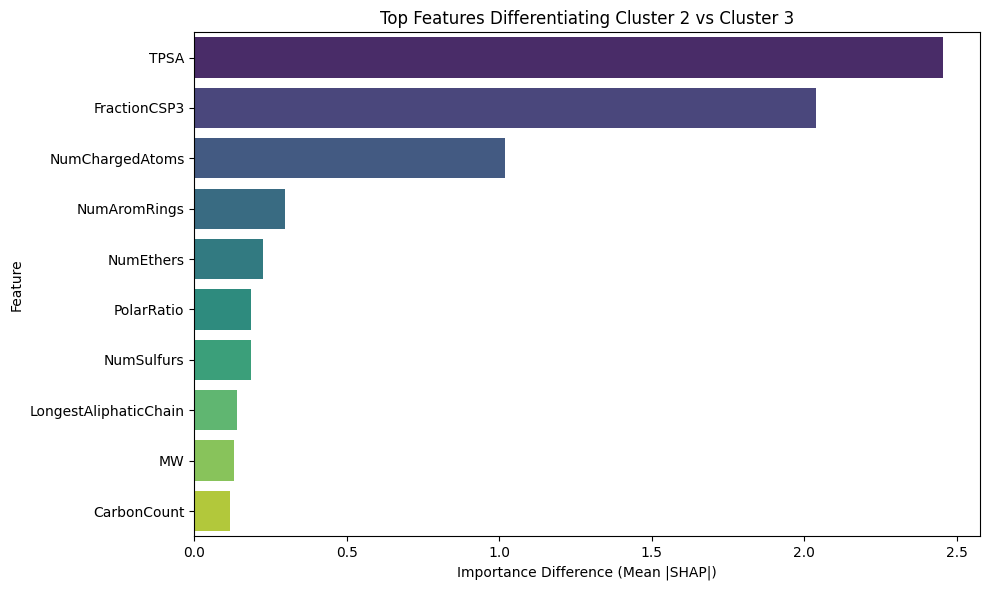

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


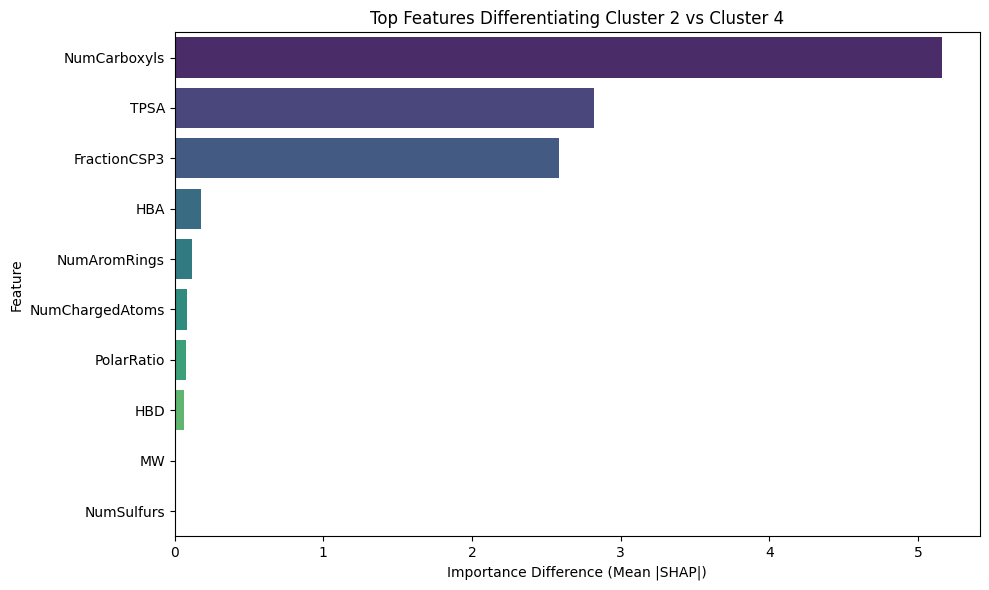

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


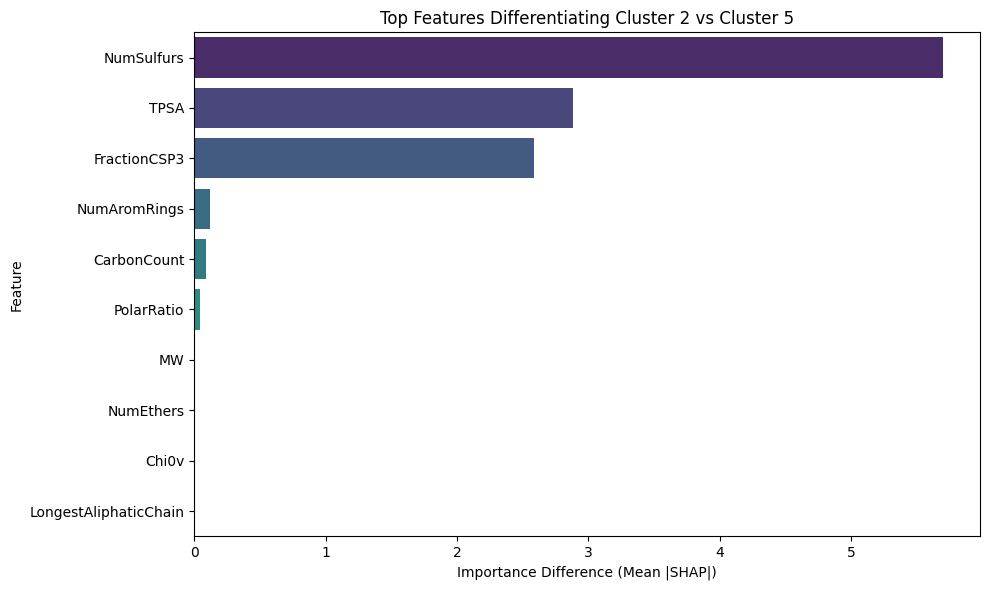

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


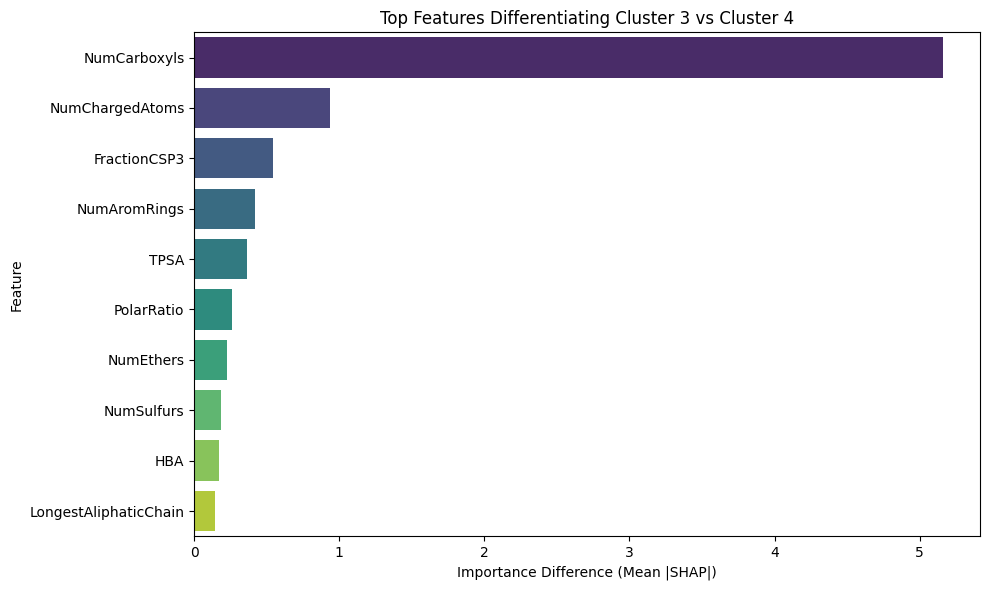

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


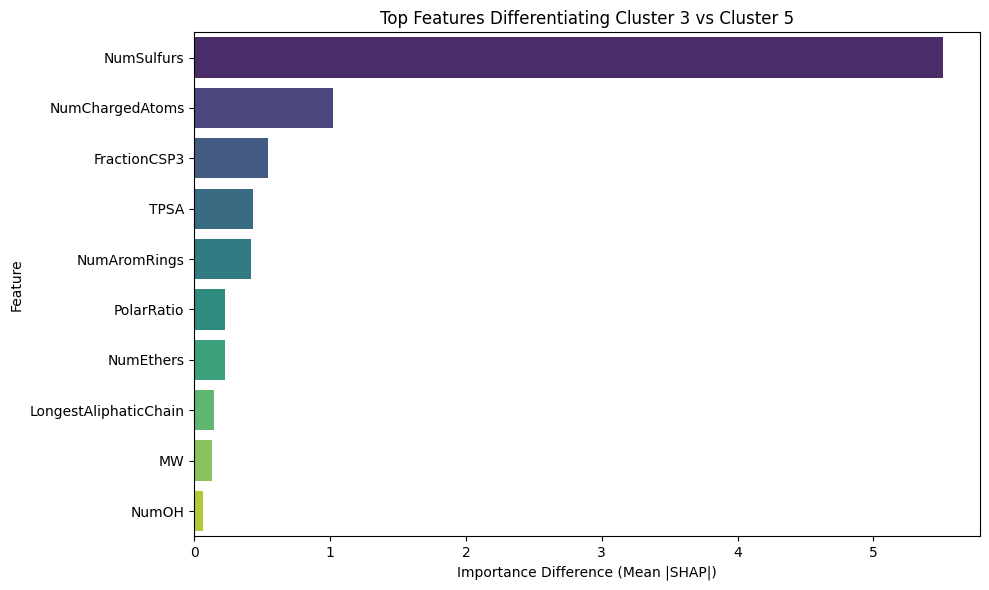

C:\Users\gtheis2\AppData\Local\Temp\ipykernel_1752\2655778780.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


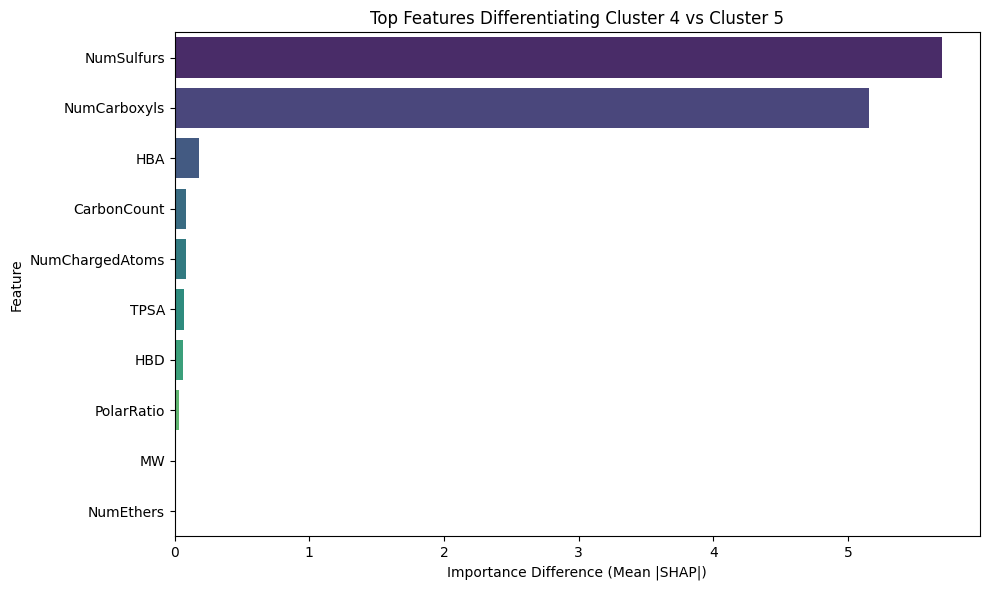

In [172]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Get all unique clusters
unique_clusters = np.unique(cluster_labels)

# Utility to get SHAP values for a given cluster
def get_cluster_shap_values(indices, predictions):
    shap_matrix = np.zeros((len(indices), X_test.shape[1]))
    for i, idx in enumerate(indices):
        shap_obj = shap_values[idx]
        shap_matrix[i, :] = shap_obj.values[:, predictions[i]]
    return np.abs(shap_matrix).mean(axis=0)

# Loop over all unique pairs of clusters
for cluster_a, cluster_b in combinations(unique_clusters, 2):
    indices_a = np.where(y_test == cluster_a)[0]
    indices_b = np.where(y_test == cluster_b)[0]

    if len(indices_a) == 0 or len(indices_b) == 0:
        print(f"Skipping pair Cluster {cluster_a} vs {cluster_b} due to missing samples.")
        continue

    preds_a = xgb_model.predict(X_test.iloc[indices_a])
    preds_b = xgb_model.predict(X_test.iloc[indices_b])

    mean_shap_a = get_cluster_shap_values(indices_a, preds_a)
    mean_shap_b = get_cluster_shap_values(indices_b, preds_b)

    diff = mean_shap_a - mean_shap_b

    df_diff = pd.DataFrame({
        'Feature': X_test.columns,
        f'Cluster {cluster_a}': mean_shap_a,
        f'Cluster {cluster_b}': mean_shap_b,
        'Importance_Difference': np.abs(diff)
    }).sort_values(by='Importance_Difference', ascending=False)

    # 📊 Plot top 10 differentiating features
    top_n = 10
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_diff.head(top_n),
        y='Feature',
        x='Importance_Difference',
        palette='viridis'
    )
    plt.title(f"Top Features Differentiating Cluster {cluster_a} vs Cluster {cluster_b}")
    plt.xlabel("Importance Difference (Mean |SHAP|)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
